# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset

### Data Context for EDA_v2
This EDA uses the assumption-pipeline output dataset: **Assumption pipline/Preprocessed_dataset_pipeline_logic.csv**.

In this pipeline, missing **Home Built Year Range** values are imputed using the mode year-range within each group of:
- Project Cost Range
- Size Of Home
- Job Type

So compared to EDA_v1, this version evaluates the same EDA flow on the updated logic-imputed dataset.

In [2]:
data = pd.read_csv('..\\Assumption pipline\\Preprocessed_dataset_pipeline_logic.csv')
data.head()

C:\Users\harsh\AppData\Local\Temp\ipykernel_10516\1674183259.py:1: DtypeWarning: Columns (0: Project ID) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('..\\Assumption pipline\\Preprocessed_dataset_pipeline_logic.csv')


,Reporting Period,Project ID,Project County,Project City,Project ZIP,Gas Utility,Electric Utility,Project Completion Date,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,...,Type Of Dwelling,Measure Type,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Home Built Year Range,Project Cost Range,Location_1_latitude,Location_1_Longitude
0,2023-06-30,577366,Broome,Endicott,13760,New York State Electric & Gas,New York State Electric & Gas,2023-06-22,9661.0,Oil,...,Single Family,Building Shell,277.0,24.0,6.826545,0,1950 - 2000,1000 - 10000,42.110115,-76.032545
1,2023-06-30,581070,Queens,Queens,11433,National Grid,Consolidated Edison,2023-06-22,11867.0,Natural Gas,...,Single Family,Building Shell,1062.0,66.0,7.221105,0,1950 - 2000,10000 - 20000,40.697715,-73.786045
2,2023-06-30,570945,Oswego,Fulton,13069,National Grid,National Grid,2023-06-20,9998.0,Natural Gas,...,Single Family,Building Shell,59.0,60.0,6.489205,0,1900 - 1950,1000 - 10000,43.325035,-76.411740
3,2023-06-30,571921,St. Lawrence,Nicholville,12965,Saint Lawrence Gas,National Grid,2023-06-13,6880.0,Oil,...,Single Family,Building Shell,482.0,15.0,6.445720,0,1950 - 2000,1000 - 10000,44.695165,-74.704765
4,2023-06-30,555646,Oswego,Cleveland,13042,National Grid,National Grid,2023-06-13,12289.0,Oil,...,Single Family,Building Shell,690.0,78.0,7.490529,0,1850-1900,10000 - 20000,43.231255,-75.868192


In [3]:
data.shape

(51934, 24)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51934 entries, 0 to 51933
Data columns (total 24 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Reporting Period                                      51934 non-null  object 
 1   Project ID                                            51934 non-null  object 
 2   Project County                                        51934 non-null  object 
 3   Project City                                          51934 non-null  object 
 4   Project ZIP                                           51934 non-null  int64  
 5   Gas Utility                                           51934 non-null  object 
 6   Electric Utility                                      51934 non-null  object 
 7   Project Completion Date                               51934 non-null  object 
 8   Total Project Cost                                    51

In [5]:
data.describe()

,Project ZIP,Total Project Cost,Size Of Home,Number Of Units,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude
count,51934.000000,51934.000000,51934.000000,51934.000000,51934.000000,51934.000000,51930.000000,51934.0,51934.000000,51934.000000
mean,13263.577695,6432.440848,1572.731717,1.058074,469.881330,31.389013,5.853971,0.0,42.488912,-76.116195
std,1300.423594,4154.131692,627.668989,2.175599,1095.349244,27.025809,0.875141,0.0,0.970511,1.834420
min,10001.000000,129.000000,800.000000,1.000000,-23368.000000,-80.000000,0.000000,0.0,40.542400,-79.745086
25%,12458.000000,3742.000000,1111.000000,1.000000,158.000000,14.000000,5.356586,0.0,42.084960,-77.636890
50%,13492.000000,5926.000000,1440.000000,1.000000,443.000000,26.000000,5.957131,0.0,42.929765,-76.112650
75%,14424.000000,8462.000000,1874.000000,1.000000,536.000000,43.000000,6.444131,0.0,43.133750,-74.044827
max,14905.000000,92297.000000,4000.000000,396.000000,38572.000000,1005.000000,10.199547,0.0,44.989856,-72.186670


# EDA

## Univariate Analysis

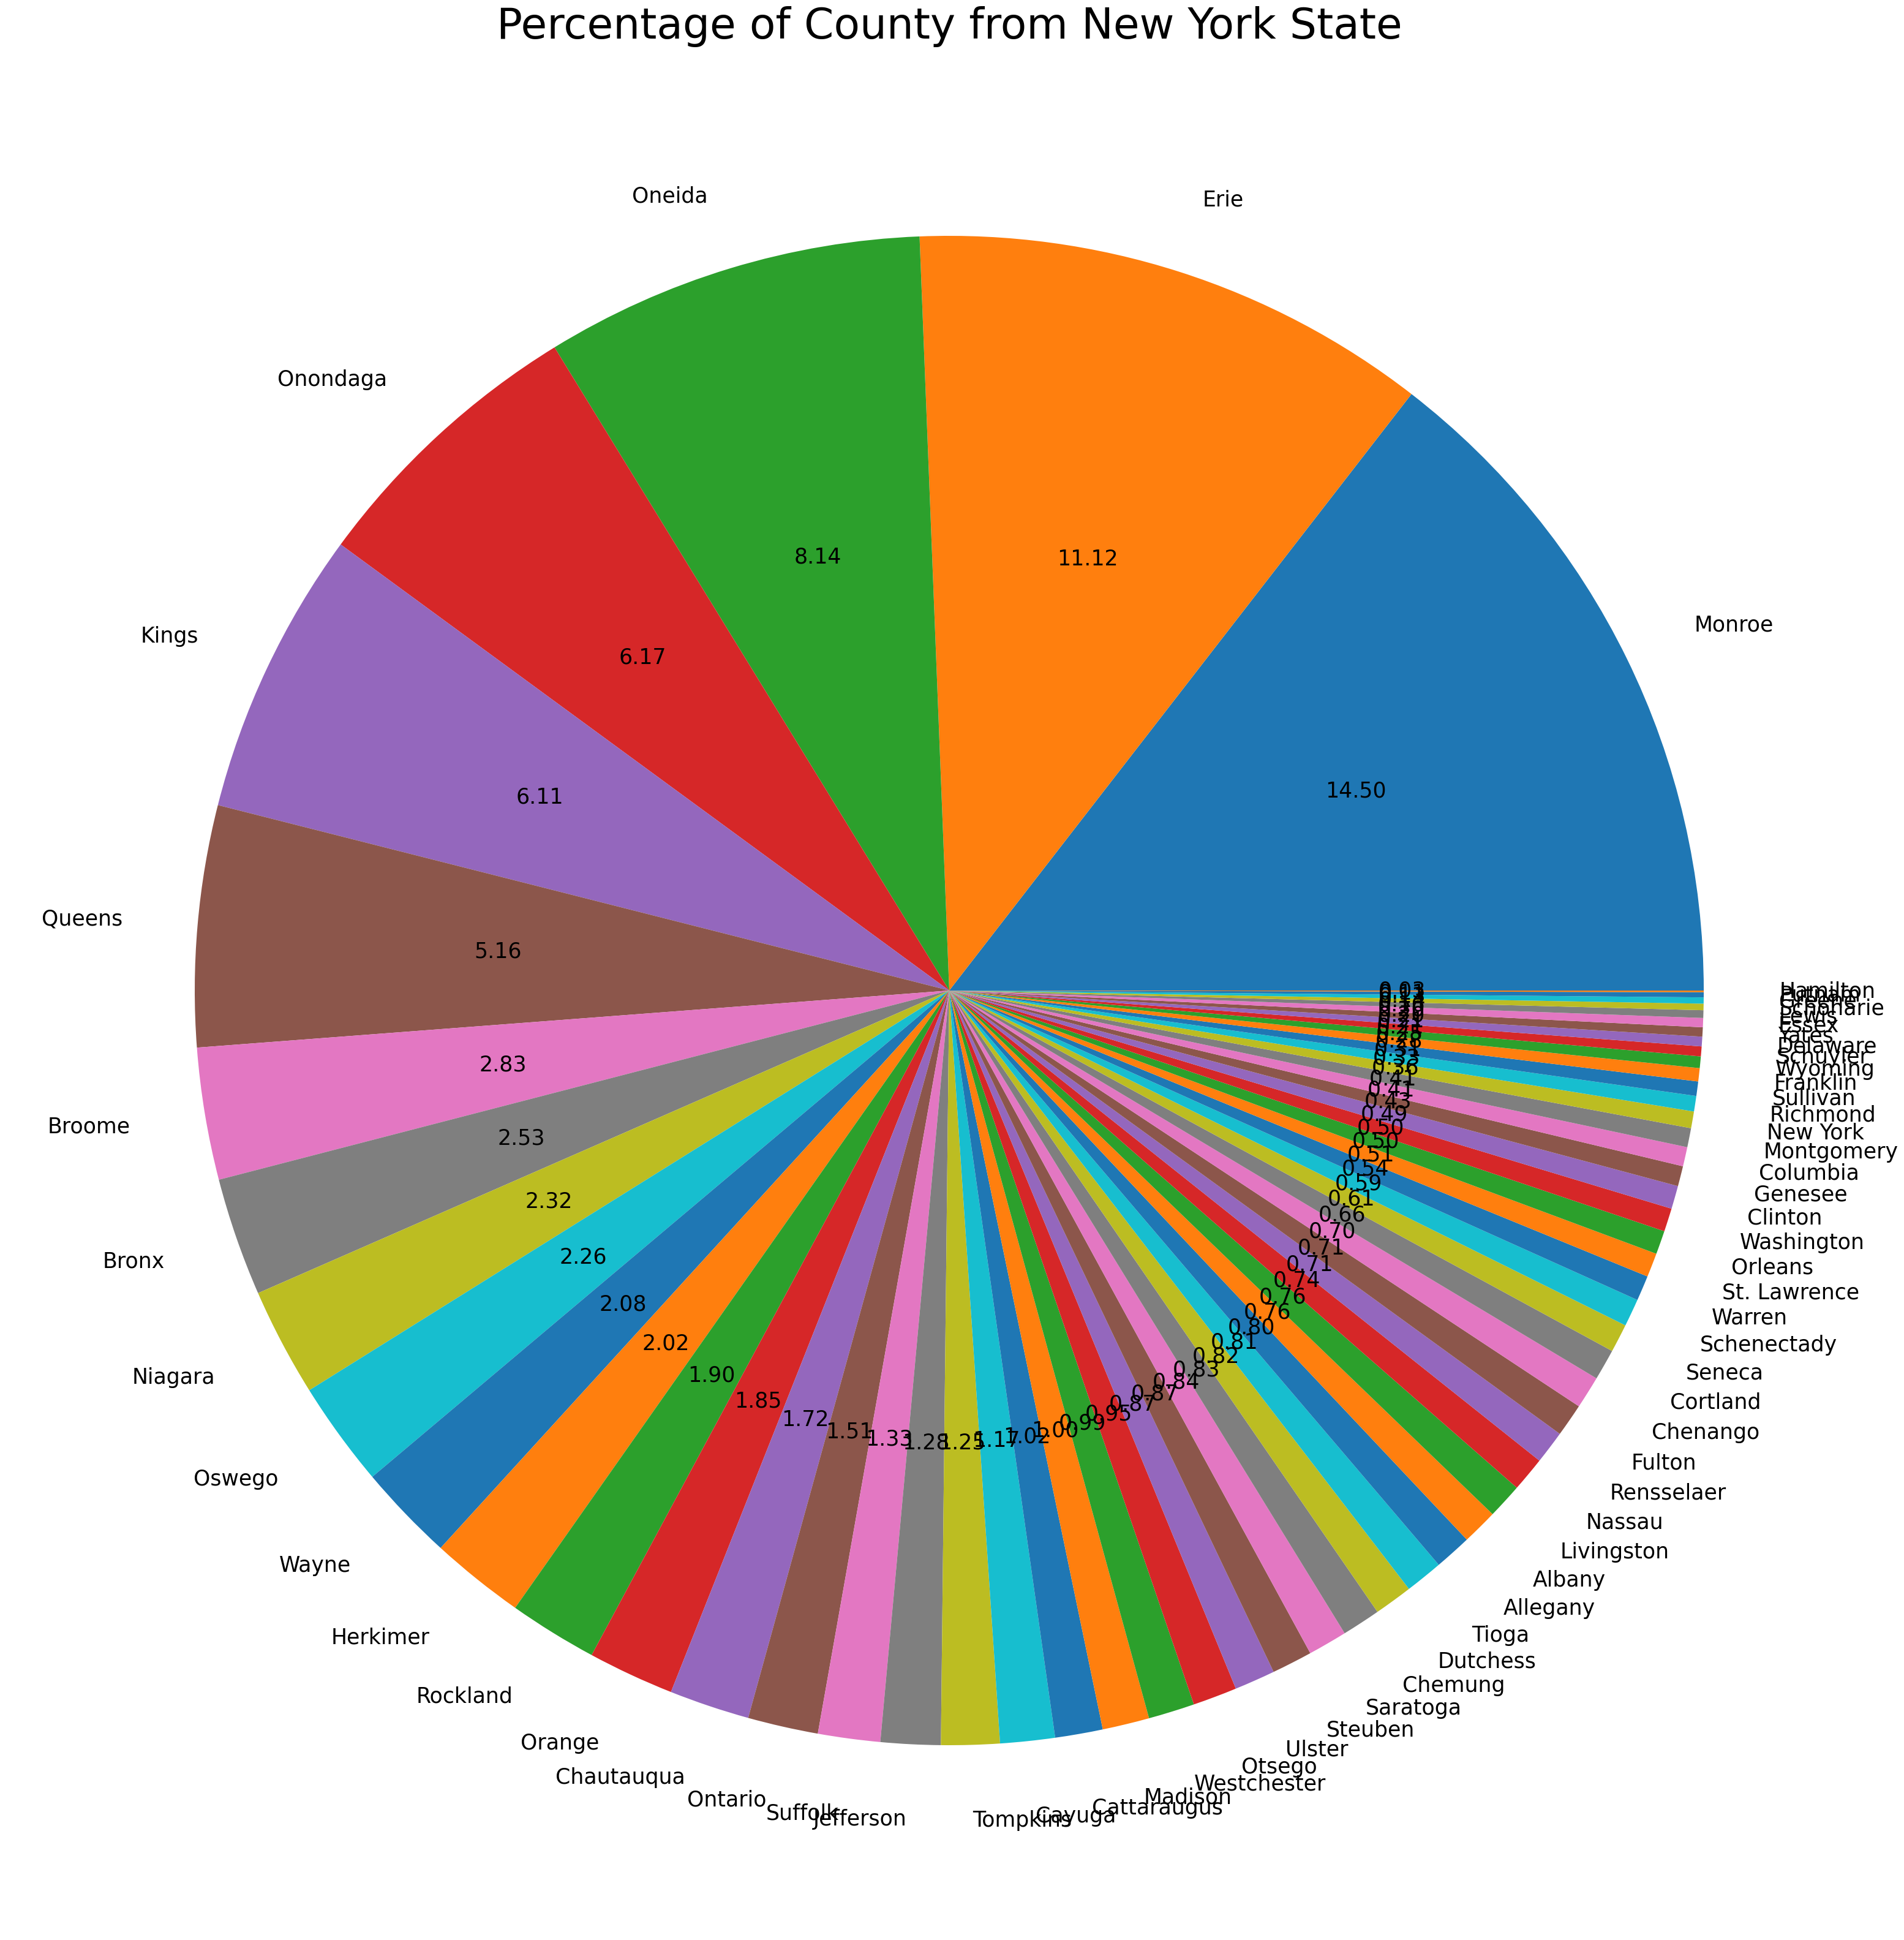

In [6]:
county_count = data['Project County'].value_counts()
plt.figure(figsize=(40,40))
plt.pie(county_count, labels= county_count.index, autopct= "%.2f", textprops={'fontsize': 25})
plt.title("Percentage of County from New York State", fontsize = "50")
plt.xticks(rotation =45)
plt.show()

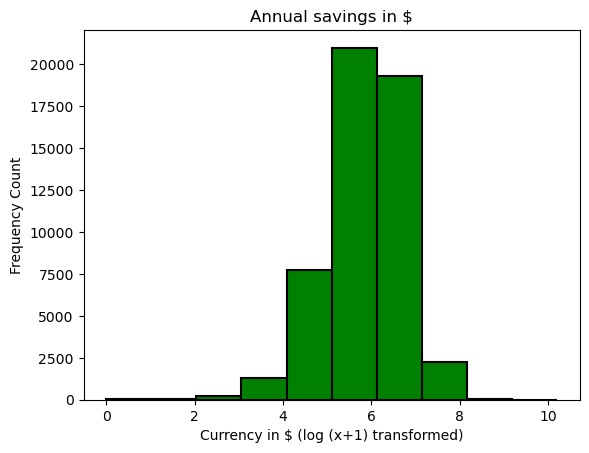

In [7]:
plt.hist(data['First Year Modeled Project Energy Savings $ Estimate'], color="green" , edgecolor='black', linewidth=1.5)
plt.title("Annual savings in $")
plt.xlabel("Currency in $ (log (x+1) transformed)")
plt.ylabel("Frequency Count")

plt.show()

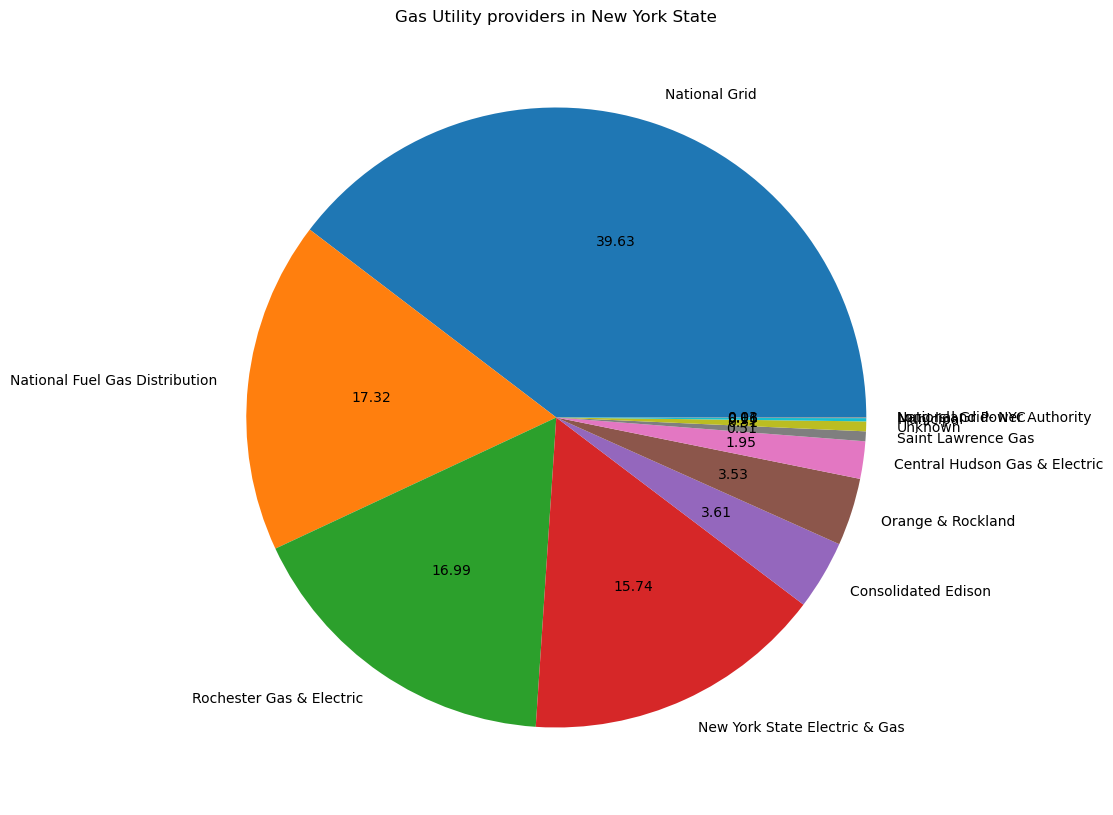

In [8]:
gau_utils = data['Gas Utility'].value_counts()

plt.figure(figsize=(10,30))
plt.pie(gau_utils, labels=gau_utils.index, autopct="%.2f")
plt.title("Gas Utility providers in New York State")
plt.show()

In [9]:
data['Gas Utility'].value_counts()

Gas Utility
National Grid                     20584
National Fuel Gas Distribution     8993
Rochester Gas & Electric           8825
New York State Electric & Gas      8176
Consolidated Edison                1877
Orange & Rockland                  1831
Central Hudson Gas & Electric      1012
Saint Lawrence Gas                  266
Unknown                             266
Municipal                            85
Long Island Power Authority          13
National Grid- NYC                    6
Name: count, dtype: int64

In [10]:
gas = data[data['Electric Utility']=="Municipal"].groupby(["Project County", "Electric Utility","Gas Utility"])['Project ID'].count()
print(gas)

Project County  Electric Utility  Gas Utility                   
Albany          Municipal         National Grid                       2
Allegany        Municipal         Municipal                           1
                                  National Fuel Gas Distribution     43
Broome          Municipal         New York State Electric & Gas      14
Cattaraugus     Municipal         Municipal                           2
                                  National Fuel Gas Distribution     39
                                  New York State Electric & Gas       1
Chautauqua      Municipal         Municipal                           7
                                  National Fuel Gas Distribution    253
                                  National Grid                       2
Chenango        Municipal         Unknown                            14
Clinton         Municipal         Municipal                           6
                                  New York State Electric & Gas       1

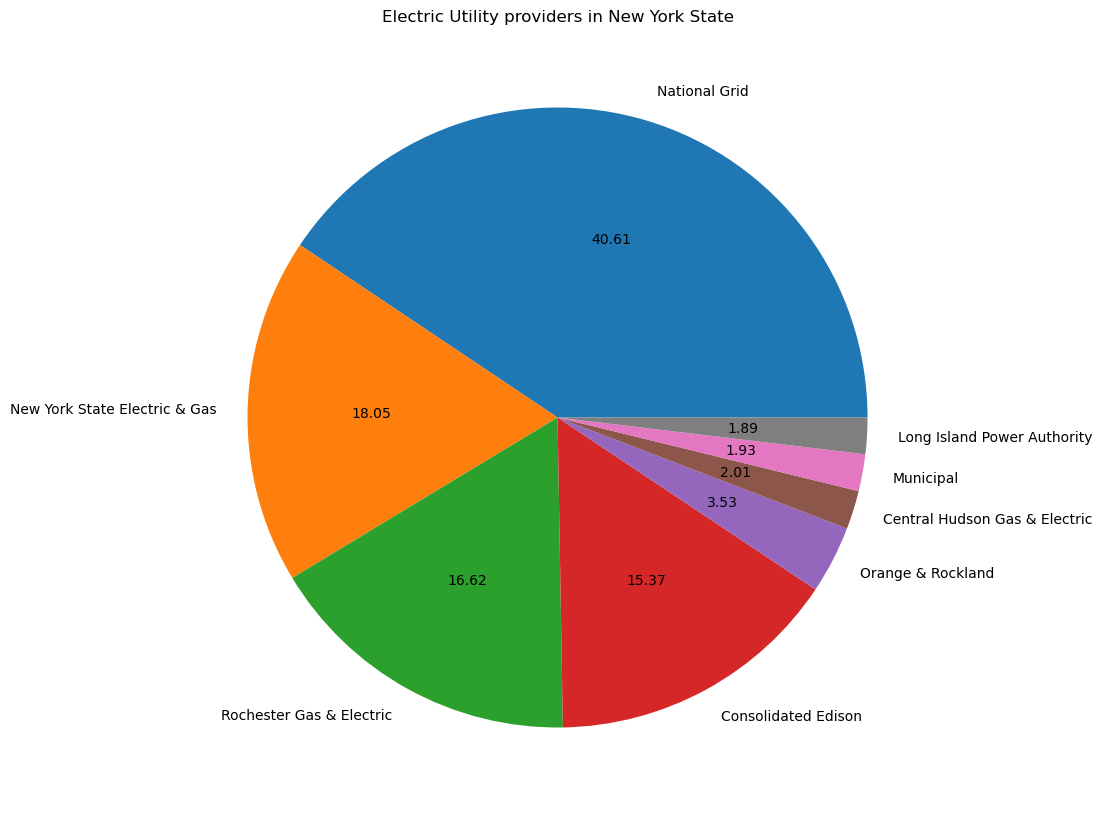

In [11]:
elec_utils = data['Electric Utility'].value_counts()

plt.figure(figsize=(10,30))
plt.pie(elec_utils, labels=elec_utils.index, autopct="%.2f")
plt.title("Electric Utility providers in New York State")
plt.show()

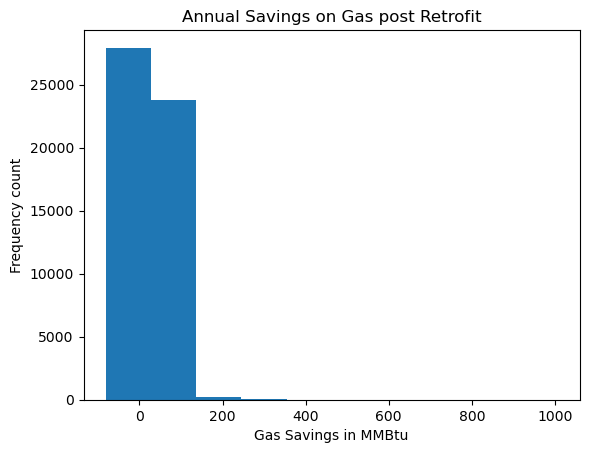

In [12]:
plt.hist(data['Estimated Annual MMBtu Savings'])
plt.title("Annual Savings on Gas post Retrofit")
plt.xlabel("Gas Savings in MMBtu")
plt.ylabel("Frequency count")
plt.show()

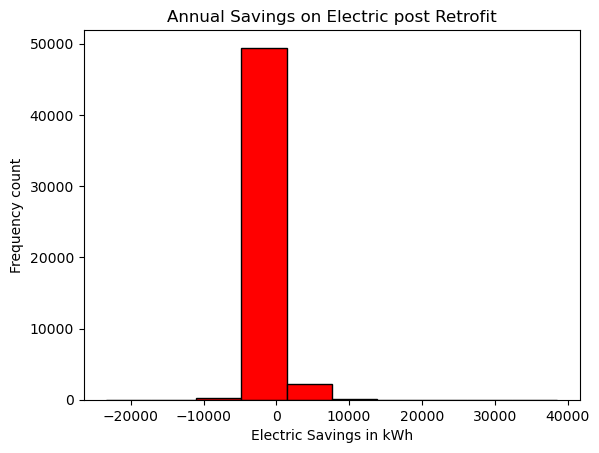

In [13]:
plt.hist(data['Estimated Annual kWh Savings'], color  ="red", edgecolor ="black")
plt.title("Annual Savings on Electric post Retrofit")
plt.xlabel("Electric Savings in kWh")
plt.ylabel("Frequency count")
plt.show()

In [14]:
from scipy.stats import skew, kurtosis

col = data['Estimated Annual kWh Savings']

print("Skewness:", skew(col, nan_policy='omit'))
print("Kurtosis:", kurtosis(col, nan_policy='omit'))

Skewness: 4.7923468379033505
Kurtosis: 194.62456740041299


### Range-Aware Analysis for Bucketed Features

In [3]:
range_pattern = r'^\s*\d+\s*-\s*\d+\s*$'

def detect_range_columns(df, sample_rows=5):
    head = df.head(sample_rows)
    range_cols = []
    normal_cols = []
    detection_rows = []

    for col in df.columns:
        head_values = head[col].dropna().astype(str).str.strip()
        head_values = head_values[head_values.ne('') & head_values.ne('Missing')]
        head_has_range = head_values.str.match(range_pattern).any()

        col_name_hint = 'range' in col.lower()
        full_values = df[col].dropna().astype(str).str.strip()
        full_values = full_values[full_values.ne('') & full_values.ne('Missing')]
        full_match_ratio = full_values.str.match(range_pattern).mean() if not full_values.empty else 0.0

        is_range_col = bool(head_has_range or (col_name_hint and full_match_ratio > 0))

        if is_range_col:
            range_cols.append(col)
            reason = 'head_match' if head_has_range else 'name_hint+full_scan'
        else:
            normal_cols.append(col)
            reason = 'no_range_signal'

        detection_rows.append({
            'Column': col,
            'Detected As': 'Range' if is_range_col else 'Normal',
            'Detection Reason': reason,
            'Head Range Match': bool(head_has_range),
            'Full Range Match %': round(float(full_match_ratio * 100), 2)
        })

    detection_df = pd.DataFrame(detection_rows)
    return range_cols, normal_cols, detection_df

def _bucket_sort_key(value):
    value = str(value).strip()
    match = pd.Series([value]).str.extract(r'^(\d+)\s*-\s*(\d+)$').iloc[0]
    if pd.notna(match[0]):
        return (0, int(match[0]), int(match[1]))
    if value.lower() == 'missing':
        return (2, np.inf, np.inf)
    return (1, np.inf, np.inf)

def summarize_bucket_column(df, col):
    total_rows = len(df)
    clean = df[col].fillna('Missing').astype(str).str.strip().replace('', 'Missing')

    counts = clean.value_counts(dropna=False).rename_axis(col).reset_index(name='Count')
    counts['Percent'] = (counts['Count'] / total_rows * 100).round(2)
    counts = counts.sort_values(by=col, key=lambda s: s.map(_bucket_sort_key)).reset_index(drop=True)

    missing_share = (clean.eq('Missing').mean() * 100).round(2)
    metrics = pd.DataFrame({
        'Column': [col],
        'Total Rows': [total_rows],
        'Unique Buckets': [clean.nunique()],
        'Missing %': [missing_share],
        'Top Bucket': [counts.loc[counts['Count'].idxmax(), col]],
        'Top Bucket %': [counts['Percent'].max()]
    })

    return counts, metrics

range_columns, normal_columns, range_detection_summary = detect_range_columns(data, sample_rows=5)

print('Range-style columns detected:', range_columns)
print('Normal-value columns detected:', len(normal_columns))
display(range_detection_summary[range_detection_summary['Detected As'] == 'Range'])

Range-style columns detected: ['Home Built Year Range', 'Project Cost Range']
Normal-value columns detected: 22


,Column,Detected As,Detection Reason,Head Range Match,Full Range Match %
20,Home Built Year Range,Range,head_match,True,99.91
21,Project Cost Range,Range,head_match,True,100.00


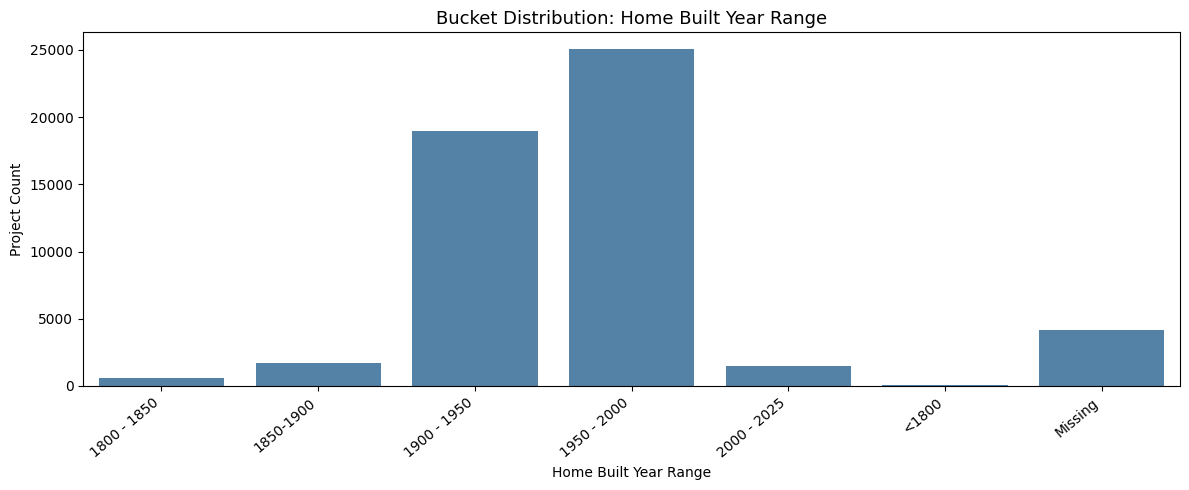

,Home Built Year Range,Count,Percent
0,1800 - 1850,562,1.08
1,1850-1900,1718,3.31
2,1900 - 1950,18939,36.47
3,1950 - 2000,25059,48.25
4,2000 - 2025,1456,2.80
5,<1800,42,0.08
6,Missing,4158,8.01


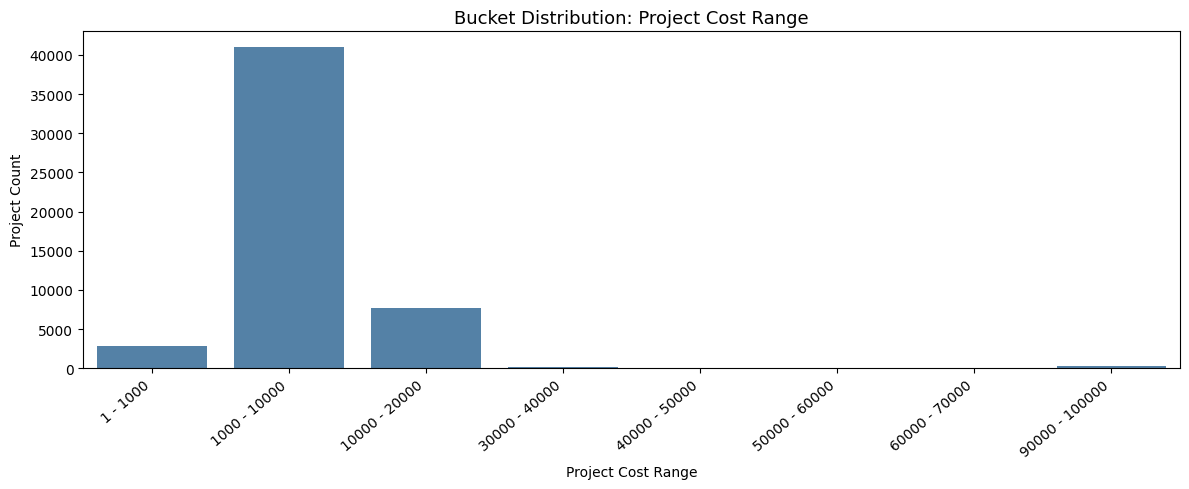

,Project Cost Range,Count,Percent
0,1 - 1000,2858,5.50
1,1000 - 10000,40962,78.87
2,10000 - 20000,7690,14.81
3,30000 - 40000,105,0.20
4,40000 - 50000,14,0.03
5,50000 - 60000,11,0.02
6,60000 - 70000,3,0.01
7,90000 - 100000,291,0.56


,Column,Total Rows,Unique Buckets,Missing %,Top Bucket,Top Bucket %
0,Home Built Year Range,51934,7,8.01,1950 - 2000,48.25
1,Project Cost Range,51934,8,0.00,1000 - 10000,78.87


In [4]:
range_metrics_all = []

for col in range_columns:
    bucket_counts, bucket_metrics = summarize_bucket_column(data, col)
    range_metrics_all.append(bucket_metrics)

    plt.figure(figsize=(12, 5))
    sns.barplot(data=bucket_counts, x=col, y='Count', color='steelblue')
    plt.title(f'Bucket Distribution: {col}', fontsize=13)
    plt.xlabel(col)
    plt.ylabel('Project Count')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

    display(bucket_counts)

range_metrics_summary = pd.concat(range_metrics_all, ignore_index=True)
display(range_metrics_summary)

### Findings 5 (Updated with Metrics)

Key metrics from the refreshed run:
- **Total projects analyzed:** 51,934
- **Range columns detected:** 2
- **Normal-value columns detected:** 22

**Home Built Year Range**
- Unique buckets: **7**
- Missing share: **59.99%** (largest bucket)
- Most common non-missing bucket: **1950 - 2000 (20.22%)**, followed by **1900 - 1950 (14.85%)**

**Project Cost Range**
- Unique buckets: **8**
- Missing share: **0.00%**
- Dominant bucket: **1000 - 10000 (78.87%)**
- Next largest: **10000 - 20000 (14.81%)** and **1 - 1000 (5.50%)**

EDA implication: comparisons and feature engineering for these columns should be bucket/ordinal based, and missingness in home-built-year needs explicit treatment before modeling.

## Bivariate Analysis

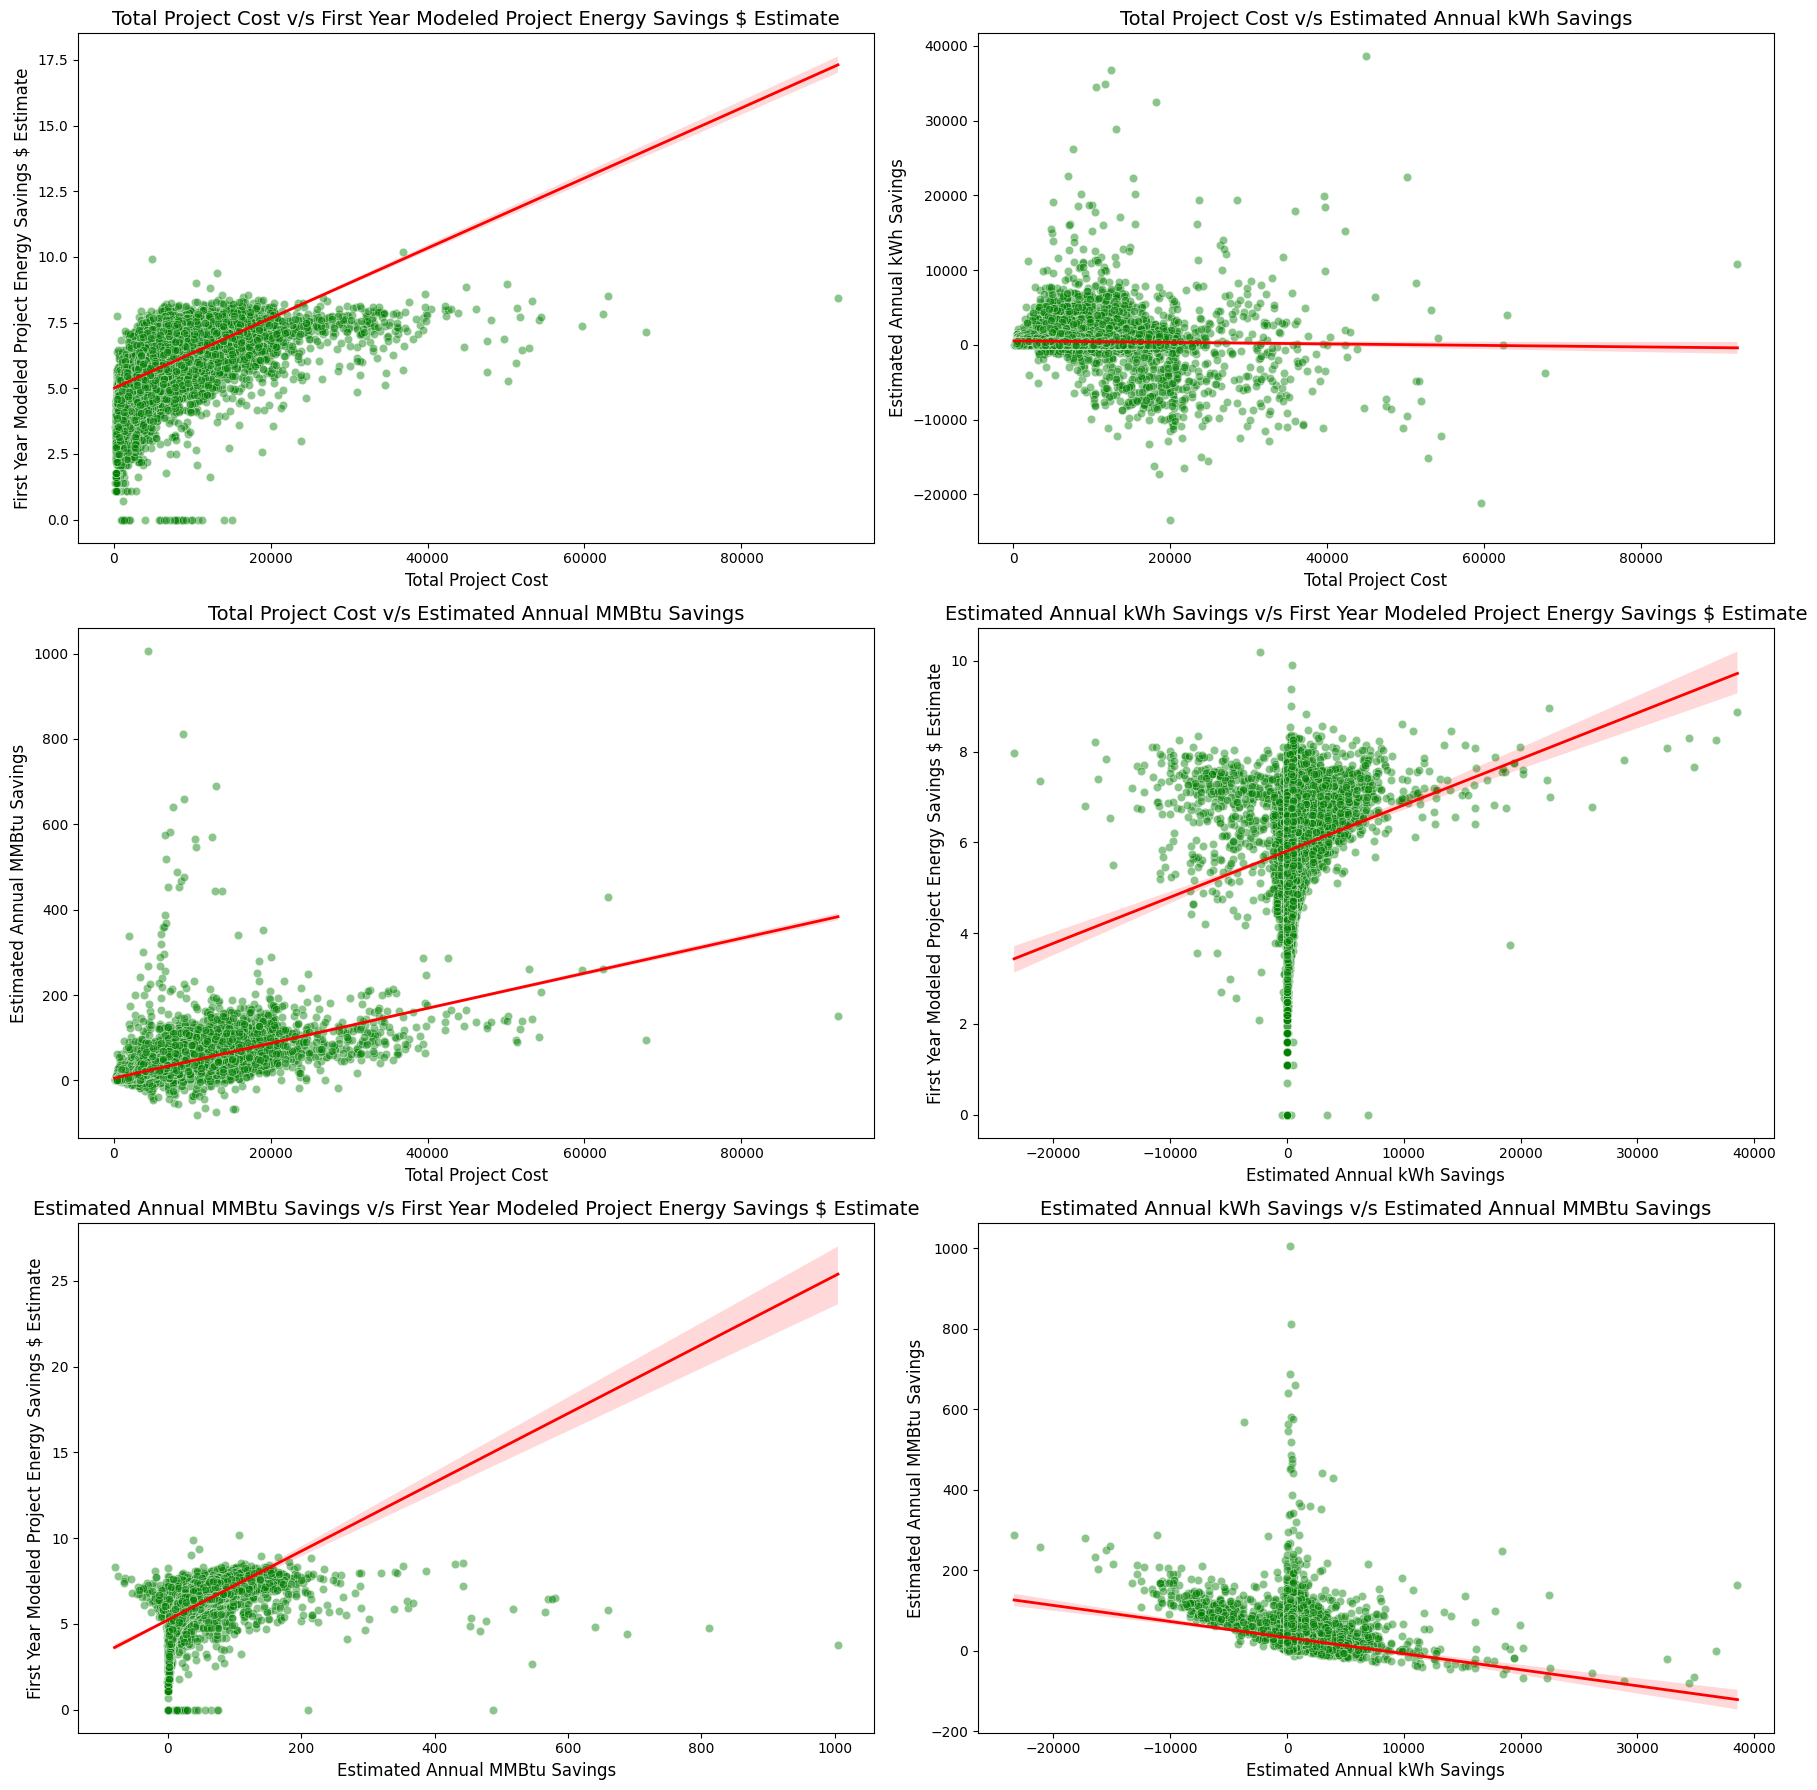

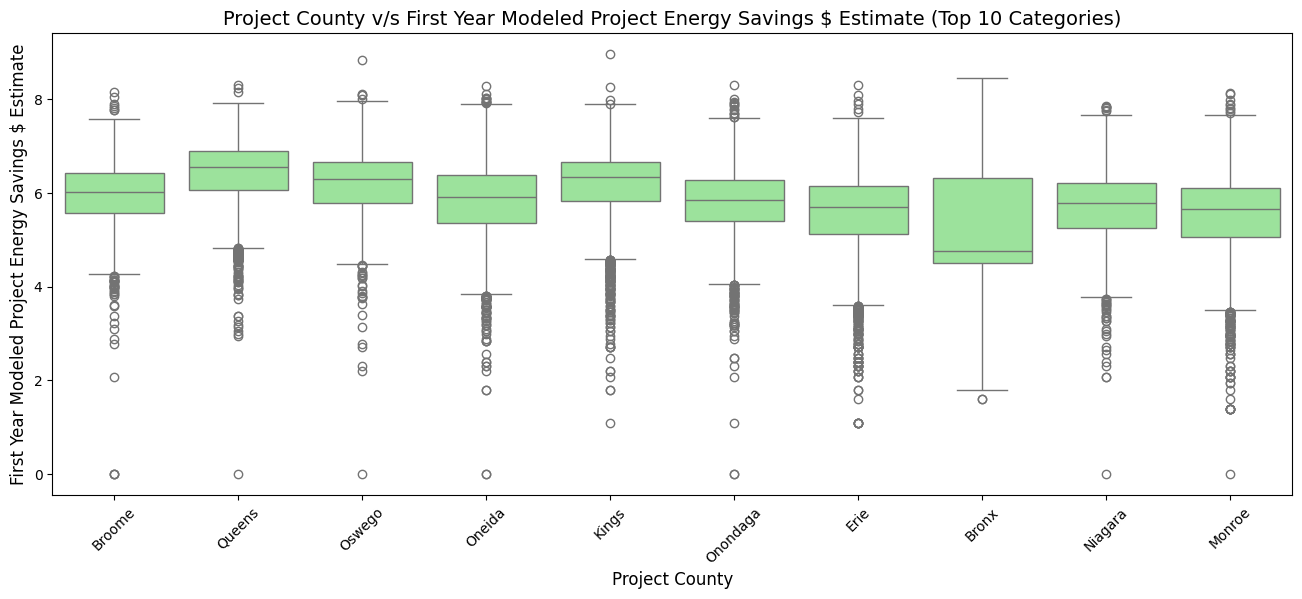

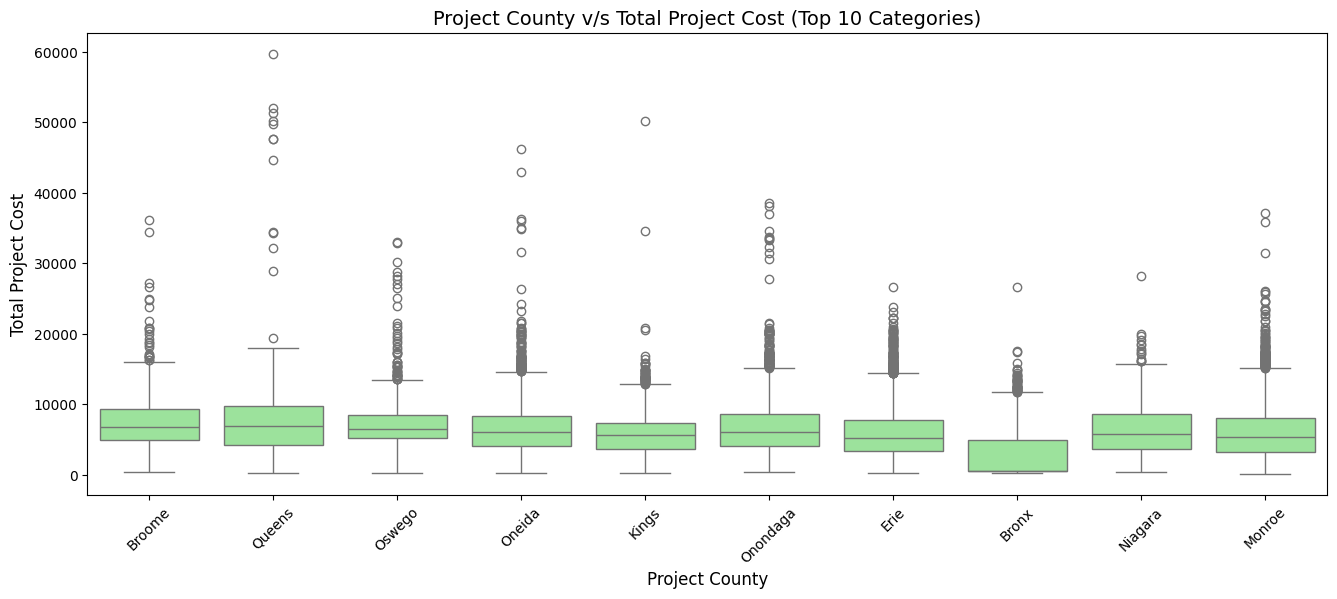

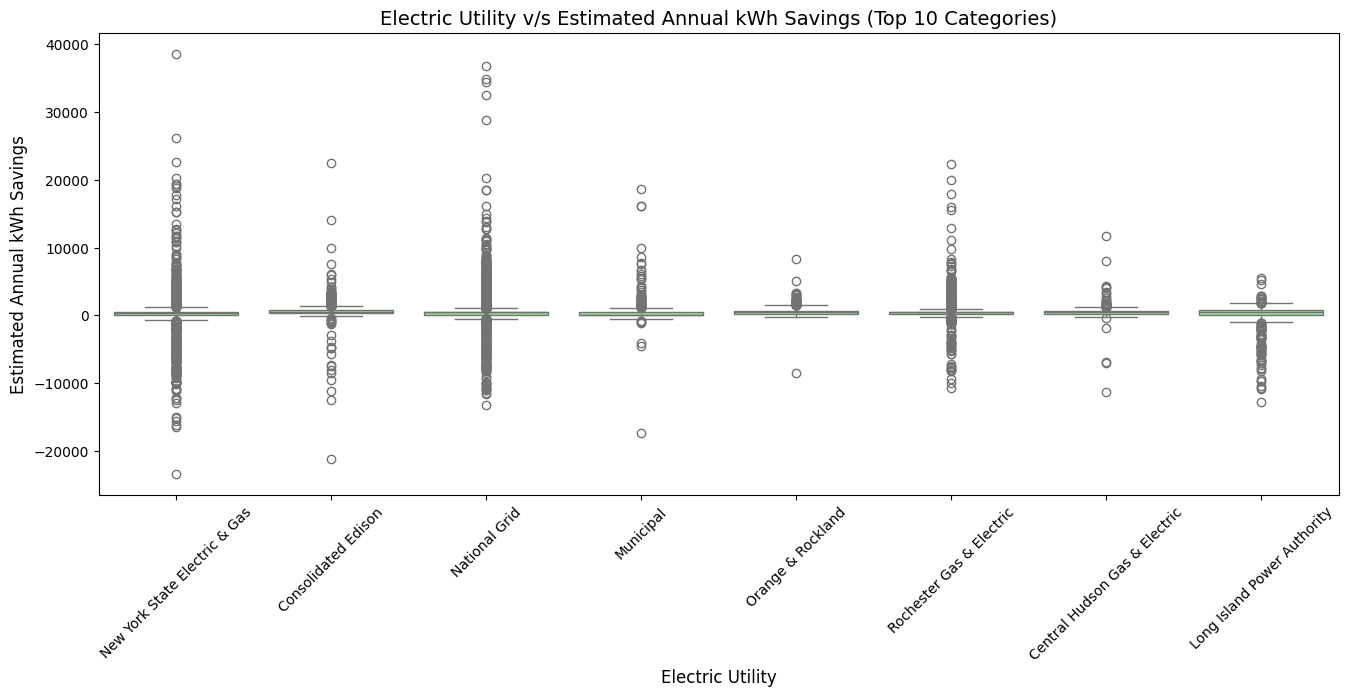

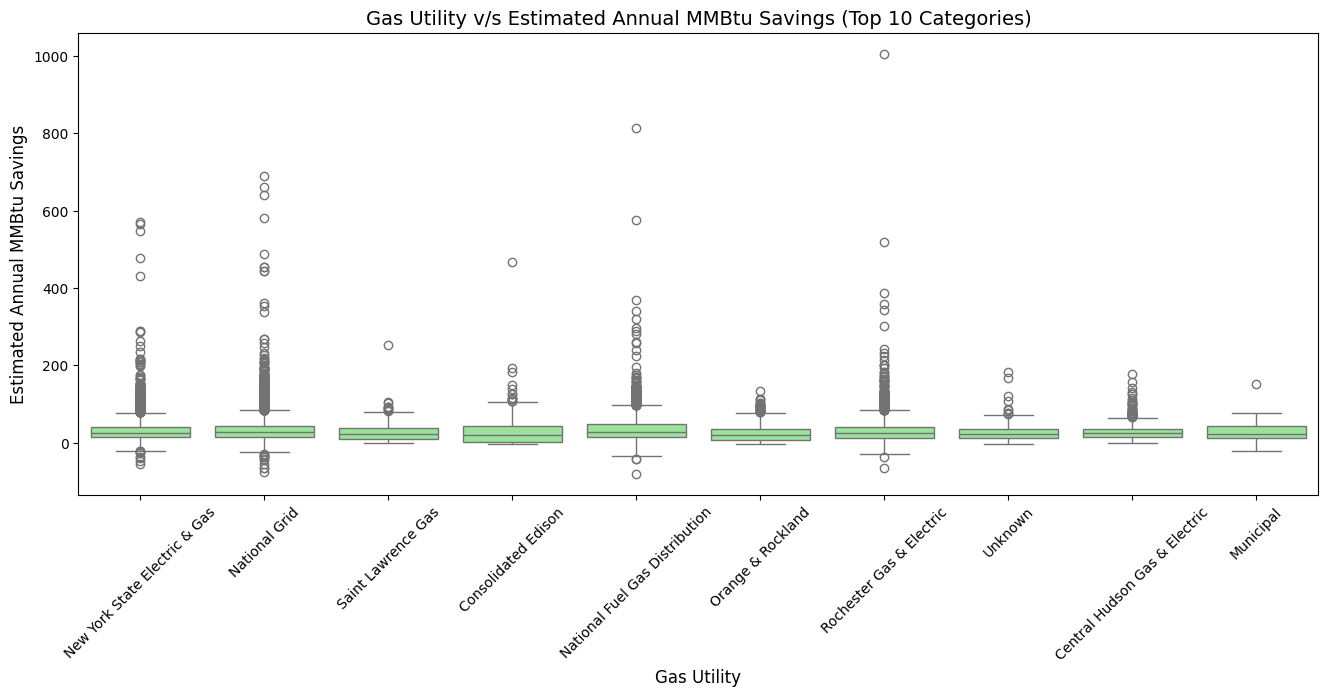

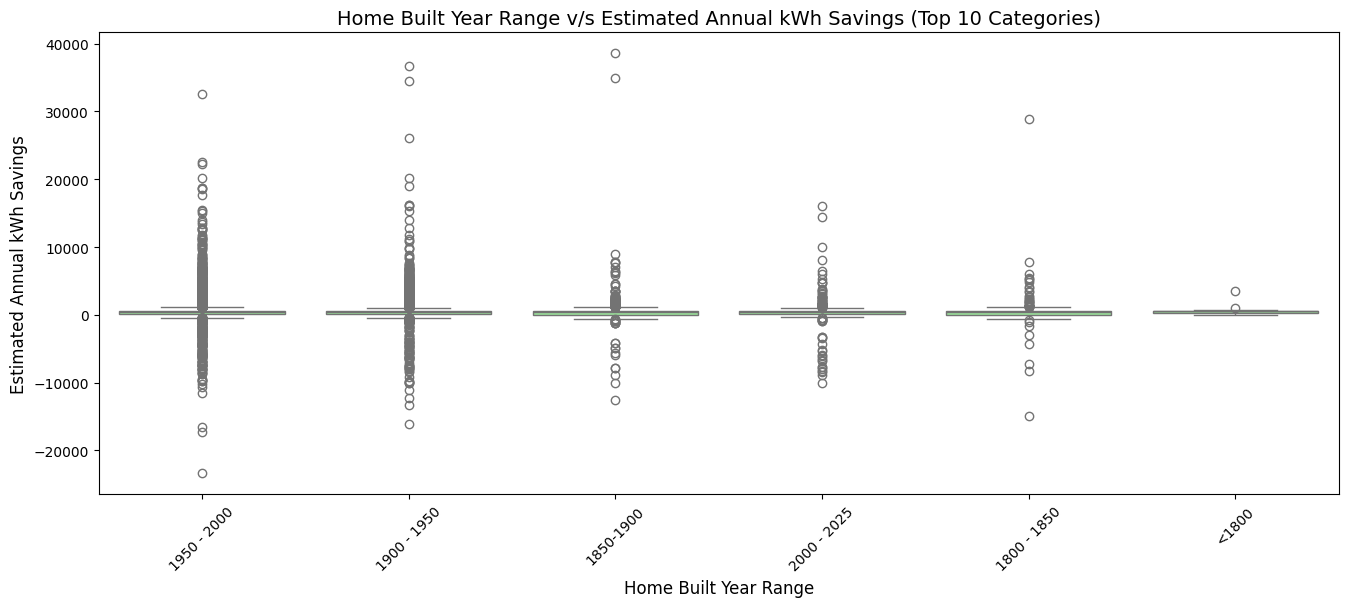

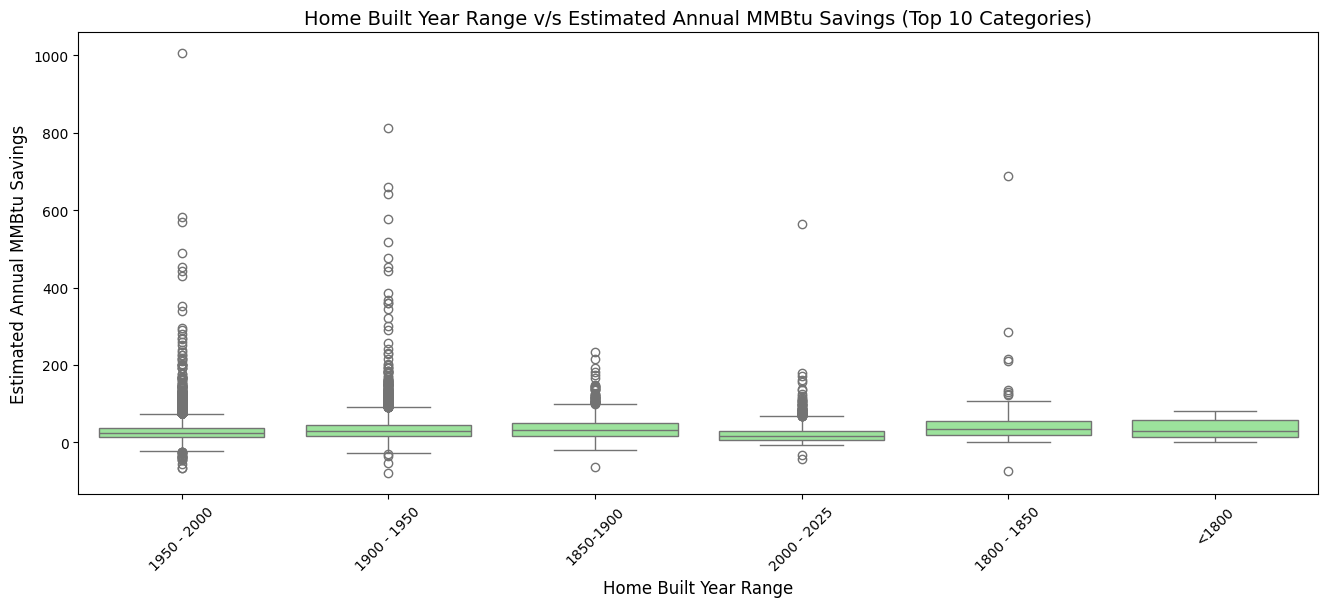

,Check,Count
10,IQR outliers in Estimated Annual kWh Savings,4943
11,IQR outliers in Estimated Annual MMBtu Savings,1529
8,IQR outliers in Total Project Cost,1228
1,Negative values in Estimated Annual kWh Savings,1157
9,IQR outliers in First Year Modeled Project Ene...,913
7,Unknown/missing-like labels in Gas Utility,266
4,Duplicate Project ID records,127
2,Negative values in Estimated Annual MMBtu Savings,123
3,Zero/negative values in Total Project Cost,0
0,Negative values in First Year Modeled Project ...,0


In [5]:
# Comprehensive Bivariate Analysis and Data Inconsistency Checks

# 1) Numeric vs Numeric meaningful comparisons
candidate_pairs = [
    ('Total Project Cost', 'First Year Modeled Project Energy Savings $ Estimate'),
    ('Total Project Cost', 'Estimated Annual kWh Savings'),
    ('Total Project Cost', 'Estimated Annual MMBtu Savings'),
    ('Estimated Annual kWh Savings', 'First Year Modeled Project Energy Savings $ Estimate'),
    ('Estimated Annual MMBtu Savings', 'First Year Modeled Project Energy Savings $ Estimate'),
    ('Estimated Annual kWh Savings', 'Estimated Annual MMBtu Savings')
]

valid_pairs = [pair for pair in candidate_pairs if pair[0] in data.columns and pair[1] in data.columns]

if len(valid_pairs) > 0:
    n = len(valid_pairs)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 6 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (x, y) in zip(axes, valid_pairs):
        plot_df = data[[x, y]].copy()
        plot_df[x] = pd.to_numeric(plot_df[x], errors='coerce')
        plot_df[y] = pd.to_numeric(plot_df[y], errors='coerce')
        plot_df = plot_df.dropna()

        if len(plot_df) < 2:
            ax.axis('off')
            continue

        sns.scatterplot(data=plot_df, x=x, y=y, color='green', alpha=0.45, ax=ax)
        sns.regplot(data=plot_df, x=x, y=y, scatter=False, color='red', line_kws={'linewidth': 2}, ax=ax)
        ax.set_title(f'{x} v/s {y}', fontsize=14)
        ax.set_xlabel(x, fontsize=12)
        ax.set_ylabel(y, fontsize=12)

    for ax in axes[len(valid_pairs):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No valid numeric-numeric pairs found in the dataset.')


# 2) Category vs Numeric meaningful comparisons (Top categories only for readability)
cat_num_candidates = [
    ('Project County', 'First Year Modeled Project Energy Savings $ Estimate'),
    ('Project County', 'Total Project Cost'),
    ('Electric Utility', 'Estimated Annual kWh Savings'),
    ('Gas Utility', 'Estimated Annual MMBtu Savings'),
    ('Home Built Year Range', 'Estimated Annual kWh Savings'),
    ('Home Built Year Range', 'Estimated Annual MMBtu Savings')
]

for cat_col, num_col in cat_num_candidates:
    if cat_col in data.columns and num_col in data.columns:
        plot_df = data[[cat_col, num_col]].copy()
        plot_df[num_col] = pd.to_numeric(plot_df[num_col], errors='coerce')
        plot_df = plot_df.dropna().copy()
        top_categories = plot_df[cat_col].value_counts().head(10).index
        plot_df = plot_df[plot_df[cat_col].isin(top_categories)]

        plt.figure(figsize=(16, 6))
        sns.boxplot(data=plot_df, x=cat_col, y=num_col, color='lightgreen')
        plt.title(f'{cat_col} v/s {num_col} (Top 10 Categories)', fontsize=14)
        plt.xlabel(cat_col, fontsize=12)
        plt.ylabel(num_col, fontsize=12)
        plt.xticks(rotation=45)
        plt.show()


# 3) Inconsistency checks to track and work on later
inconsistency_report = []

# Negative value checks for savings columns
savings_cols = [
    'First Year Modeled Project Energy Savings $ Estimate',
    'Estimated Annual kWh Savings',
    'Estimated Annual MMBtu Savings'
]
for col in savings_cols:
    if col in data.columns:
        temp = pd.to_numeric(data[col], errors='coerce')
        inconsistency_report.append({
            'Check': f'Negative values in {col}',
            'Count': int((temp < 0).sum())
        })

# Non-positive project cost check
if 'Total Project Cost' in data.columns:
    temp_cost = pd.to_numeric(data['Total Project Cost'], errors='coerce')
    inconsistency_report.append({
        'Check': 'Zero/negative values in Total Project Cost',
        'Count': int((temp_cost <= 0).sum())
    })

# Duplicate Project ID check
if 'Project ID' in data.columns:
    inconsistency_report.append({
        'Check': 'Duplicate Project ID records',
        'Count': int(data['Project ID'].duplicated().sum())
    })

# Missing/unknown string category checks
unknown_tokens = {'', 'unknown', 'unk', 'n/a', 'na', 'none', 'nan', 'null'}
for col in ['Project County', 'Electric Utility', 'Gas Utility']:
    if col in data.columns:
        series = data[col].astype(str).str.strip().str.lower()
        inconsistency_report.append({
            'Check': f'Unknown/missing-like labels in {col}',
            'Count': int(series.isin(unknown_tokens).sum())
        })

# IQR outlier checks for key numeric columns
key_numeric_cols = [
    'Total Project Cost',
    'First Year Modeled Project Energy Savings $ Estimate',
    'Estimated Annual kWh Savings',
    'Estimated Annual MMBtu Savings'
]
for col in key_numeric_cols:
    if col in data.columns:
        temp = pd.to_numeric(data[col], errors='coerce').dropna()
        if len(temp) > 0:
            q1 = temp.quantile(0.25)
            q3 = temp.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            outliers = int(((temp < lower) | (temp > upper)).sum())
            inconsistency_report.append({
                'Check': f'IQR outliers in {col}',
                'Count': outliers
            })

inconsistency_df = pd.DataFrame(inconsistency_report).sort_values('Count', ascending=False)
inconsistency_df

### Findings 6

Bivariate plots suggest that relationship strength differs by utility and county, and the numeric relationships are non-linear in multiple places. The inconsistency report highlights where data-quality work is needed before modeling.

## Multivariate Analysis

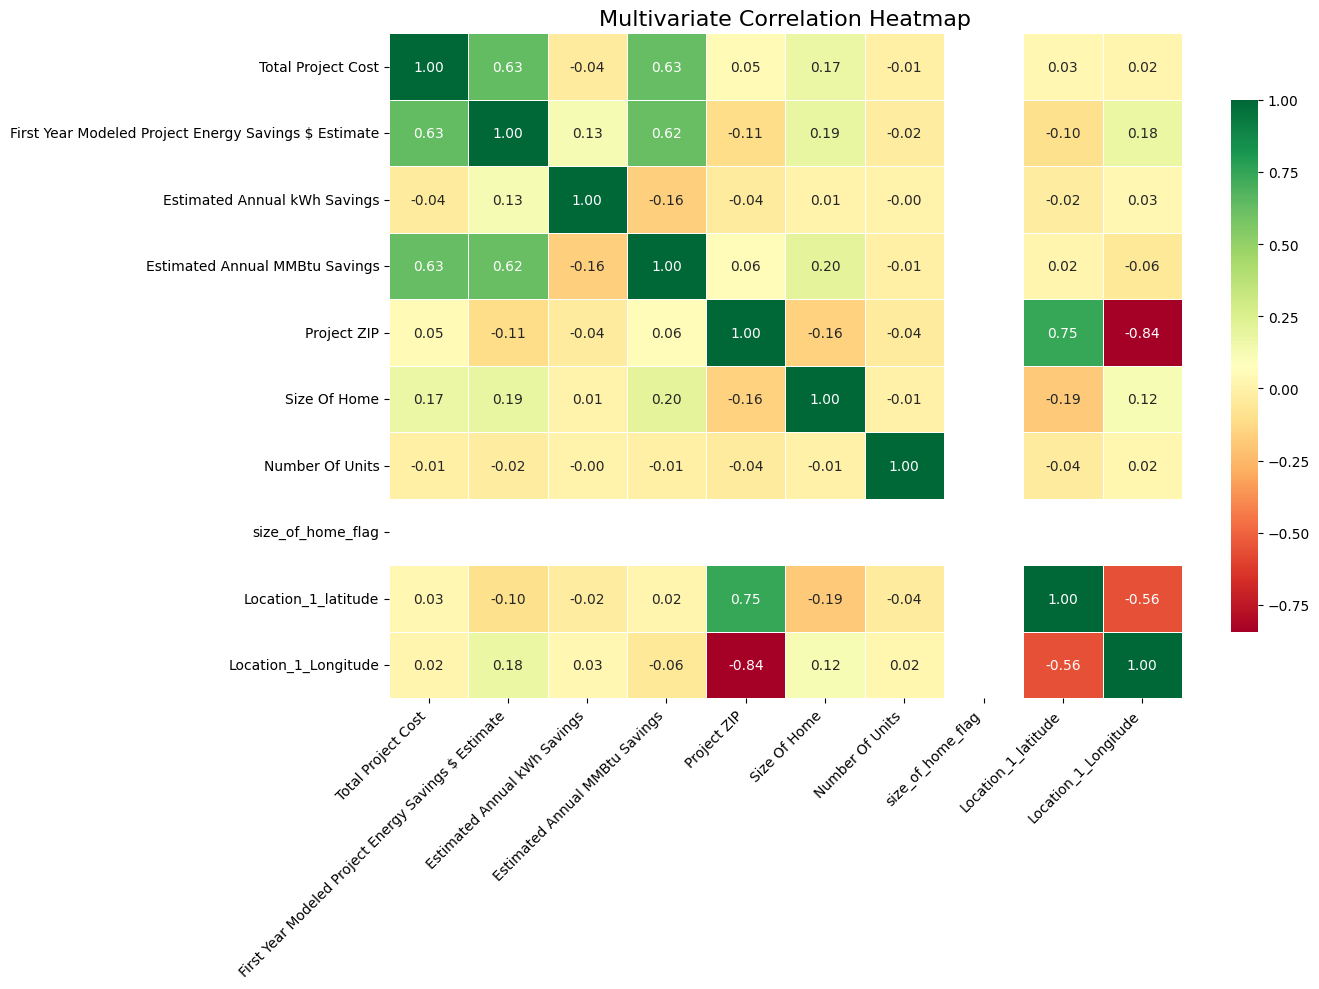

In [7]:
# Correlation Heatmap (Multivariate starter)

priority_cols = [
    'Total Project Cost',
    'First Year Modeled Project Energy Savings $ Estimate',
    'Estimated Annual kWh Savings',
    'Estimated Annual MMBtu Savings',
    'Year Home Built'
]

available_priority = [col for col in priority_cols if col in data.columns]
all_numeric = data.select_dtypes(include=[np.number]).columns.tolist()

# Keep key variables first and add remaining numeric columns if needed
heatmap_cols = available_priority + [col for col in all_numeric if col not in available_priority]

# Limit columns for readability if there are too many numeric features
if len(heatmap_cols) > 12:
    heatmap_cols = heatmap_cols[:12]

corr_df = data[heatmap_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_df,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
 )
plt.title('Multivariate Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Findings 7

The heatmap provides an initial multivariate view of how cost, modeled savings, and utility-based savings interact. Strongly correlated feature groups can guide feature selection and collinearity checks before model training.

### Pairplot Analysis

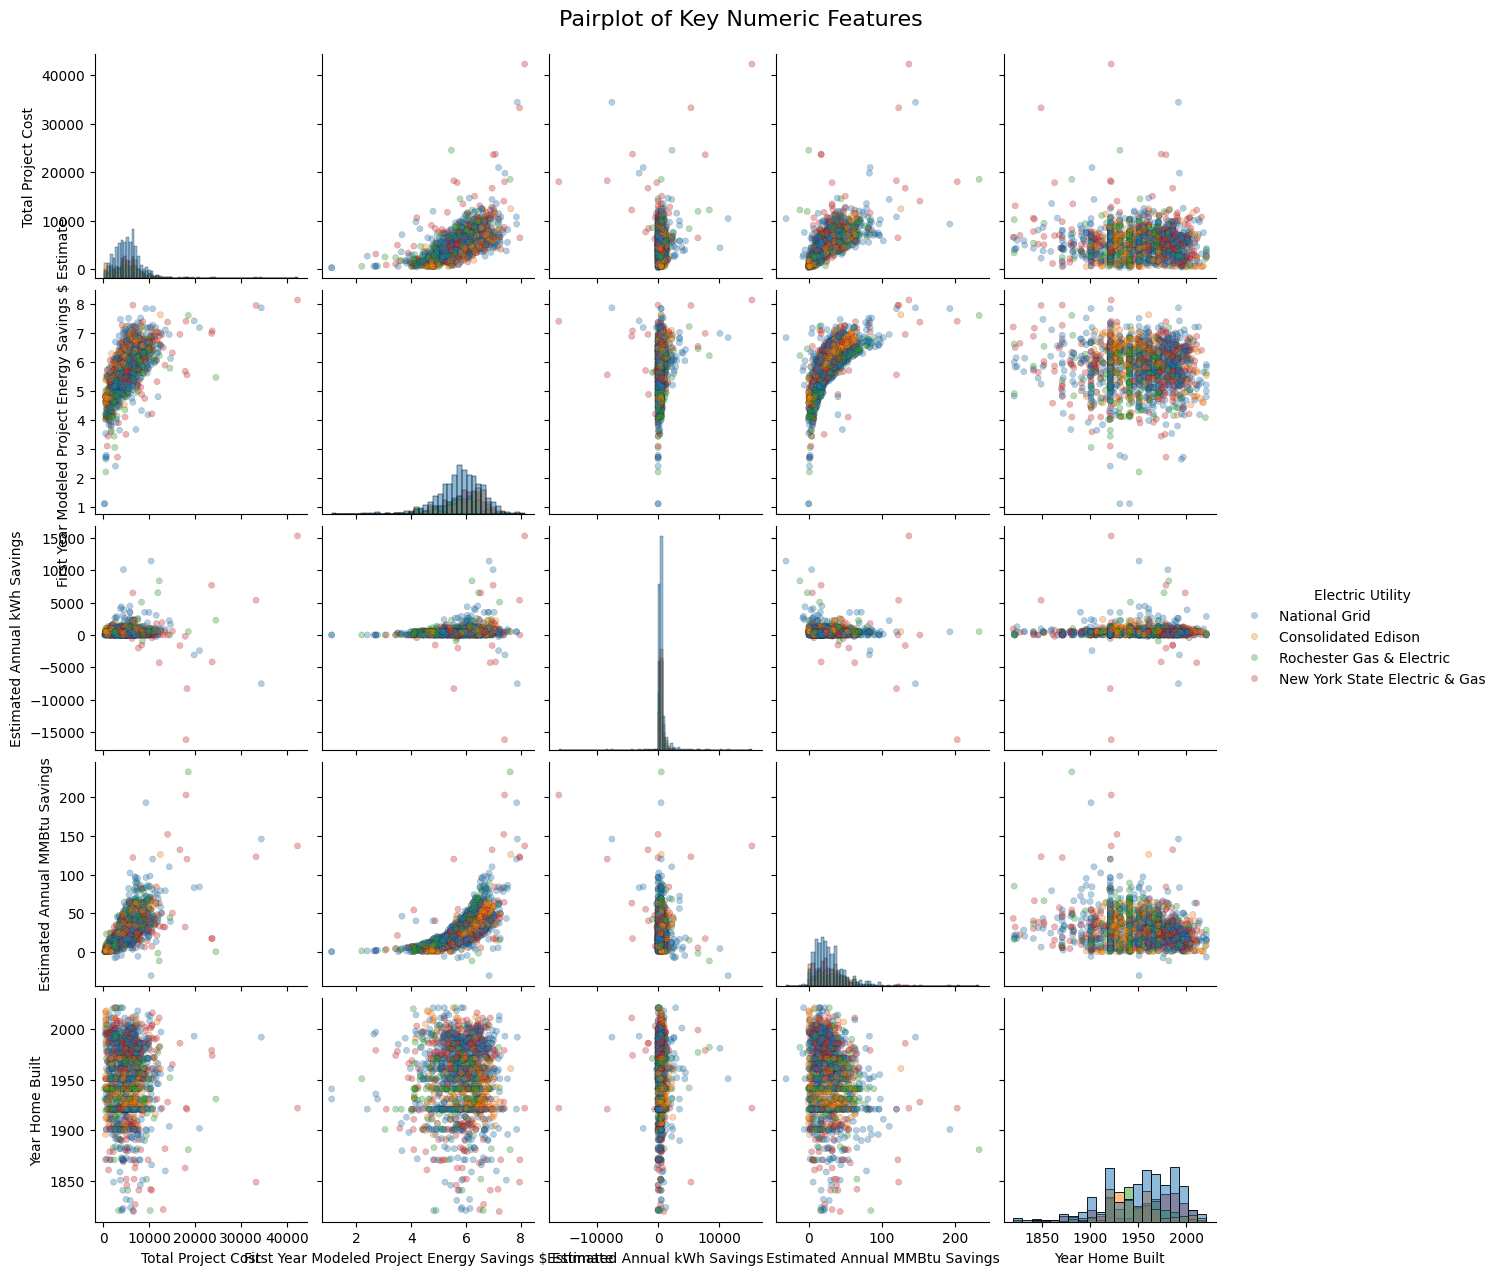

In [8]:
# Pairplot for key multivariate relationships

pairplot_cols = [
    'Total Project Cost',
    'First Year Modeled Project Energy Savings $ Estimate',
    'Estimated Annual kWh Savings',
    'Estimated Annual MMBtu Savings',
    'Year Home Built'
 ]

pairplot_cols = [col for col in pairplot_cols if col in data.columns]

# Build a clean numeric-only frame first to avoid seaborn dtype errors
base_cols = pairplot_cols.copy()
if 'Electric Utility' in data.columns:
    base_cols = pairplot_cols + ['Electric Utility']

pairplot_df = data[base_cols].copy()
for c in pairplot_cols:
    pairplot_df[c] = pd.to_numeric(pairplot_df[c], errors='coerce')
pairplot_df = pairplot_df.dropna(subset=pairplot_cols).copy()

hue_col = None
if 'Electric Utility' in pairplot_df.columns:
    top_utils = pairplot_df['Electric Utility'].value_counts().head(4).index
    pairplot_df = pairplot_df[pairplot_df['Electric Utility'].isin(top_utils)].copy()
    if pairplot_df['Electric Utility'].nunique() > 1:
        hue_col = 'Electric Utility'

# Downsample for faster rendering if dataset is large
sample_size = 1500
if len(pairplot_df) > sample_size:
    pairplot_df = pairplot_df.sample(sample_size, random_state=42)

sns.pairplot(
    pairplot_df,
    vars=pairplot_cols,
    hue=hue_col,
    diag_kind='hist',
    plot_kws={'alpha': 0.35, 's': 20, 'edgecolor': 'black', 'linewidth': 0.2}
 )
plt.suptitle('Pairplot of Key Numeric Features', y=1.02, fontsize=16)
plt.show()

### Findings 8

The pairplot reveals pairwise trends, spread, and potential non-linear relationships among cost and savings variables. Clustered patterns by electric utility (for top categories) can indicate utility-specific behavior that may be useful for feature engineering later.

In [6]:
# Report metrics for EDA_v2 (assumption-pipeline dataset)
import numpy as np
import pandas as pd

df = data.copy()

# Snapshot metrics
total_rows = int(len(df))
total_cols = int(df.shape[1])

# Savings estimate diagnostics
s_col = 'First Year Modeled Project Energy Savings $ Estimate'
s = pd.to_numeric(df[s_col], errors='coerce')
savings_zero = int((s == 0).sum())
savings_null = int(s.isna().sum())
savings_negative = int((s < 0).sum())
non_null_count = int(s.notna().sum())
savings_zero_share_non_null_pct = round((savings_zero / non_null_count * 100) if non_null_count else 0.0, 2)

# Home-built range missingness
hby_col = 'Home Built Year Range'
hby_missing = int(df[hby_col].astype(str).str.strip().eq('Missing').sum()) if hby_col in df.columns else np.nan
hby_missing_pct = round((hby_missing / total_rows * 100), 2) if hby_col in df.columns and total_rows else np.nan

# Project cost range concentration
pcr_col = 'Project Cost Range'
pcr_vc = df[pcr_col].astype(str).value_counts(dropna=False) if pcr_col in df.columns else pd.Series(dtype='int64')
top_pcr = str(pcr_vc.index[0]) if len(pcr_vc) else 'N/A'
top_pcr_pct = round((pcr_vc.iloc[0] / total_rows * 100), 2) if len(pcr_vc) and total_rows else 0.0
second_pcr = str(pcr_vc.index[1]) if len(pcr_vc) > 1 else 'N/A'
second_pcr_pct = round((pcr_vc.iloc[1] / total_rows * 100), 2) if len(pcr_vc) > 1 and total_rows else 0.0

# Duplicate Project ID diagnostics
pid_col = 'Project ID'
dup_mask = df[pid_col].duplicated(keep=False)
dup_rows = df.loc[dup_mask].copy()
duplicate_rows = int(len(dup_rows))
duplicate_unique_project_ids = int(dup_rows[pid_col].nunique())

proxy_cols = [
    c for c in [
        'Project County', 'Project City', 'Project ZIP',
        'Location_1_latitude', 'Location_1_Longitude',
        'Size Of Home', 'Type Of Dwelling', 'Number Of Units'
    ] if c in dup_rows.columns
]

def is_same_building_proxy(group):
    for c in proxy_cols:
        vals = group[c].astype(str).str.strip().replace('nan', np.nan).dropna().unique()
        if len(vals) > 1:
            return False
    return True

dup_groups = []
for pid, g in dup_rows.groupby(pid_col, dropna=False):
    same_proxy = is_same_building_proxy(g)
    dup_groups.append({
        'Project ID': pid,
        'Rows': int(len(g)),
        'Same Building Proxy': bool(same_proxy)
    })

dup_summary = pd.DataFrame(dup_groups)
duplicate_same_building_ids = int(dup_summary['Same Building Proxy'].sum()) if len(dup_summary) else 0
duplicate_mixed_proxy_ids = int((~dup_summary['Same Building Proxy']).sum()) if len(dup_summary) else 0
duplicate_mixed_proxy_id_list = dup_summary.loc[~dup_summary['Same Building Proxy'], 'Project ID'].astype(str).tolist() if len(dup_summary) else []

likely_multi_unit_id_list = []
if 'Number Of Units' in dup_rows.columns:
    for pid, g in dup_rows.groupby(pid_col, dropna=False):
        if is_same_building_proxy(g):
            units = pd.to_numeric(g['Number Of Units'], errors='coerce')
            if (units > 1).any():
                likely_multi_unit_id_list.append(str(pid))
duplicate_likely_multi_unit_ids = len(likely_multi_unit_id_list)

# Additional quality alerts
cost_non_positive = int((pd.to_numeric(df['Total Project Cost'], errors='coerce') <= 0).sum()) if 'Total Project Cost' in df.columns else 0
kwh_negative = int((pd.to_numeric(df['Estimated Annual kWh Savings'], errors='coerce') < 0).sum()) if 'Estimated Annual kWh Savings' in df.columns else 0
mmbtu_negative = int((pd.to_numeric(df['Estimated Annual MMBtu Savings'], errors='coerce') < 0).sum()) if 'Estimated Annual MMBtu Savings' in df.columns else 0

report_values_v2 = {
    'total_rows': total_rows,
    'total_columns': total_cols,
    'home_built_missing': hby_missing,
    'home_built_missing_pct': hby_missing_pct,
    'top_project_cost_range': top_pcr,
    'top_project_cost_range_pct': top_pcr_pct,
    'second_project_cost_range': second_pcr,
    'second_project_cost_range_pct': second_pcr_pct,
    'savings_zero': savings_zero,
    'savings_null': savings_null,
    'savings_negative': savings_negative,
    'savings_zero_share_non_null_pct': savings_zero_share_non_null_pct,
    'duplicate_rows': duplicate_rows,
    'duplicate_unique_project_ids': duplicate_unique_project_ids,
    'duplicate_same_building_ids': duplicate_same_building_ids,
    'duplicate_mixed_proxy_ids': duplicate_mixed_proxy_ids,
    'duplicate_mixed_proxy_id_list': duplicate_mixed_proxy_id_list,
    'duplicate_likely_multi_unit_ids': duplicate_likely_multi_unit_ids,
    'duplicate_likely_multi_unit_id_list': likely_multi_unit_id_list,
    'cost_non_positive': cost_non_positive,
    'kwh_negative': kwh_negative,
    'mmbtu_negative': mmbtu_negative
}

print(report_values_v2)

{'total_rows': 51934, 'total_columns': 24, 'home_built_missing': 0, 'home_built_missing_pct': 0.0, 'top_project_cost_range': '1000 - 10000', 'top_project_cost_range_pct': np.float64(78.87), 'second_project_cost_range': '10000 - 20000', 'second_project_cost_range_pct': np.float64(14.81), 'savings_zero': 27, 'savings_null': 4, 'savings_negative': 0, 'savings_zero_share_non_null_pct': 0.05, 'duplicate_rows': 254, 'duplicate_unique_project_ids': 127, 'duplicate_same_building_ids': 122, 'duplicate_mixed_proxy_ids': 5, 'duplicate_mixed_proxy_id_list': ['548946', '550244', '556256', '557829', '567832'], 'duplicate_likely_multi_unit_ids': 4, 'duplicate_likely_multi_unit_id_list': ['531138', '534463', '548922', '556181'], 'cost_non_positive': 0, 'kwh_negative': 1157, 'mmbtu_negative': 123}


## Final Consolidated EDA_v2 Report

### 1) Dataset Snapshot
- Total records analyzed: **51,934**
- Total columns: **24**
- Source dataset: **Assumption pipline/Preprocessed_dataset_pipeline_logic.csv**
- Range-style columns identified: **2**
  - Home Built Year Range
  - Project Cost Range
- Normal-value columns identified: **22**

### 2) What Changed in EDA_v2
This dataset uses assumption-pipeline logic where missing **Home Built Year Range** values are imputed by mode within grouped combinations of:
- Project Cost Range
- Size Of Home
- Job Type

### 3) Core Findings
- **Imputation impact is clear**: Home Built Year Range missing values in this dataset are **0 (0.00%)**.
- **Cost buckets remain highly concentrated**:
  - Top bucket: **1000 - 10000 (78.87%)**
  - Second bucket: **10000 - 20000 (14.81%)**
- **Savings estimate zeros are real values**: First Year Modeled Project Energy Savings $ Estimate has zeros but no negatives.
- **Most duplicate Project IDs still look same-building repeats**, with a smaller subset requiring manual review.
- **Multivariate behavior remains non-linear** with heavy outlier spread in kWh/MMBtu savings.

### 4) Quantified Metrics
#### Savings Estimate vs Project Cost
- Zero savings estimate records: **27**
- Null savings estimate records: **4**
- Negative savings estimate records: **0**
- Zero-share among non-null modeled savings estimate: **0.05%**

#### Duplicate Project ID Analysis
- Duplicate rows (all repeated entries): **254**
- Unique duplicate Project IDs: **127**
- Same-building proxy duplicate IDs: **122**
- Mixed-building proxy duplicate IDs: **5**
- Mixed-proxy IDs: **548946, 550244, 556256, 557829, 567832**
- Likely multi-unit/condo-style IDs: **4**
- Likely multi-unit IDs: **531138, 534463, 548922, 556181**

### 5) Missingness and Data Gaps
- Home Built Year Range missing share: **0.00%** (imputation removed previous missingness in this engineered feature).
- First Year Modeled Project Energy Savings $ Estimate nulls: **4** records.
- Project Cost Range missing share: **0.00%**.

### 6) Additional Data-Quality Alerts
- Estimated Annual kWh Savings negative values: **1,157**
- Estimated Annual MMBtu Savings negative values: **123**
- Total Project Cost non-positive values: **0**

### 7) Recommended Next Steps
1. **Duplicate resolution**: manually review the 5 mixed-proxy duplicate IDs and finalize merge/drop policy.
2. **Post-imputation validation**: compare model performance between EDA_v1 and EDA_v2 to quantify impact of home-built range imputation.
3. **Savings sanity rules**: validate business meaning of negative kWh/MMBtu values before modeling.
4. **Feature engineering**: retain Project Cost Range and Home Built Year Range as ordered categorical features.
5. **Robust modeling setup**: use outlier-resistant preprocessing/modeling due to heavy-tail behavior in savings variables.
6. **Versioned reporting**: keep EDA_v1 (pre-imputation style) and EDA_v2 (assumption-pipeline style) side-by-side for auditability.